In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.xlsx to diabetes.xlsx


In [6]:
print(uploaded.keys())

dict_keys(['diabetes.xlsx'])


In [10]:
df = pd.read_excel('diabetes.xlsx')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Basic info
print(df.shape)
print("\n")
print(df.info())
print("\n")
print(df.describe())

(768, 9)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.7994

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
import numpy as np

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Check how many missing now
print(df.isnull().sum())
print("\nPercentage missing:")
print((df.isnull().sum() / len(df)) * 100)

# Fill missing values with median (better than mean for clinical data)
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

print("\nAfter cleaning - missing values:")
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Percentage missing:
Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64

After cleaning - missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


/tmp/ipykernel_6838/894911038.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0,0], palette='Set2')
/tmp/ipykernel_6838/894911038.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Non-Diabetic', 'Diabetic'])
/tmp/ipykernel_6838/894911038.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[1,0], palette='Set2')
/tmp/ipykernel_6838/894911038.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xt

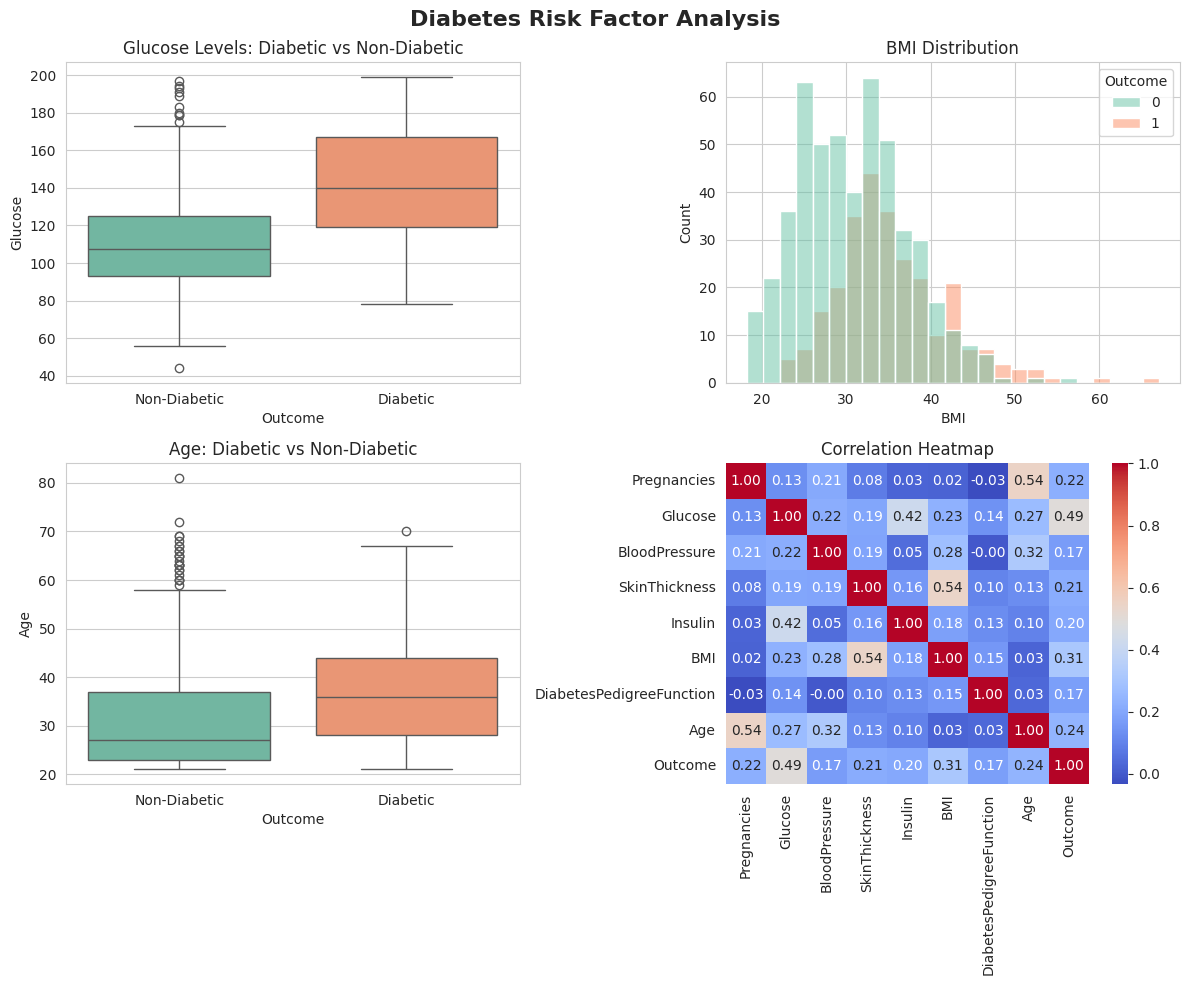

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Diabetes Risk Factor Analysis', fontsize=16, fontweight='bold')

# 1. Glucose distribution by outcome
sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Glucose Levels: Diabetic vs Non-Diabetic')
axes[0,0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

# 2. BMI distribution
sns.histplot(data=df, x='BMI', hue='Outcome', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('BMI Distribution')

# 3. Age distribution
sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Age: Diabetic vs Non-Diabetic')
axes[1,0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

# 4. Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm')
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('diabetes_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from scipy import stats

# T-test: compare glucose between diabetic vs non-diabetic
diabetic = df[df['Outcome']==1]['Glucose']
non_diabetic = df[df['Outcome']==0]['Glucose']

t_stat, p_value = stats.ttest_ind(diabetic, non_diabetic)
print(f"Glucose T-test:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Significant difference in glucose between groups!")

Glucose T-test:
T-statistic: 15.6738
P-value: 0.000000
Significant difference in glucose between groups!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df.drop('Outcome', axis=1)
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 75.32%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred,
                                target_names=['Non-Diabetic', 'Diabetic'],
                                output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(2)
print(report_df.to_string())

              precision  recall  f1-score  support
Non-Diabetic       0.80    0.83      0.81    99.00
Diabetic           0.67    0.62      0.64    55.00
accuracy           0.75    0.75      0.75     0.75
macro avg          0.73    0.72      0.73   154.00
weighted avg       0.75    0.75      0.75   154.00


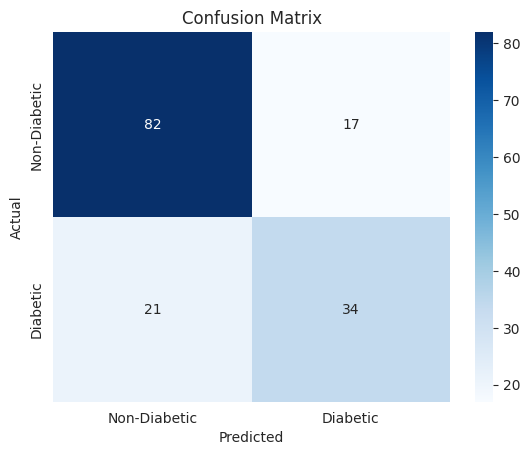

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()